In [1]:
# data_preprocess.py

import pandas as pd


def read_data(train_file="dataset/train.tsv"):
    train_df = pd.read_csv(train_file, sep="\t")
    return train_df["Phrase"].values, train_df["Sentiment"].values

In [2]:
# feature_extraction

import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Ensure the stopwords are downloaded on your machine
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)

# Initialize these once globally so the program doesn't waste time reloading them for every sentence

STOP_WORDS = set(stopwords.words("english")).union(set("ok"))
STEMMER = PorterStemmer()


def clean_text(text):
    """
    Standardizes text by lowercasing, removing punctuation,
    removing stop words, and stemming the core words.
    """
    # 1. Lowercase the text
    text = text.lower()

    # 2. Remove special characters (keep only a-z and spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # 3. Tokenize (split into a list of words)
    words = text.split()

    # 4. Remove Stop Words and Stem the remaining words
    cleaned_words = [STEMMER.stem(w) for w in words if w not in STOP_WORDS]

    return cleaned_words


class BagOfWord:
    def __init__(self):
        self.vocab = {}

    def fit(self, sent_list):
        for sent in sent_list:
            # We use our new text cleaner here!
            words = clean_text(sent)
            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = len(self.vocab)

    def transform(self, sent_list):
        vocab_size = len(self.vocab)
        # Using int8 to save memory!
        bag_of_word_feature = np.zeros((len(sent_list), vocab_size), dtype=np.int8)

        for idx, sent in enumerate(sent_list):
            words = clean_text(sent)
            for word in words:
                if word in self.vocab:
                    bag_of_word_feature[idx][self.vocab[word]] += 1

        return bag_of_word_feature

    def fit_transform(self, sent_list):
        self.fit(sent_list)
        return self.transform(sent_list)


class NGram:
    def __init__(self, ngram):
        self.ngram = ngram
        self.feature_map = {}

    def fit(self, sentList):
        for gram in self.ngram:
            for sent in sentList:
                words = clean_text(sent)
                # Create N-grams from the cleaned word list
                for i in range(len(words) - gram + 1):
                    feature = "_".join(words[i : i + gram])
                    if feature not in self.feature_map:
                        self.feature_map[feature] = len(self.feature_map)

    def transform(self, sentList):
        n = len(sentList)
        m = len(self.feature_map)
        # Using int8 to save memory!
        ngram_feature = np.zeros((n, m), dtype=np.int8)

        for idx, sent in enumerate(sentList):
            words = clean_text(sent)
            for gram in self.ngram:
                for i in range(len(words) - gram + 1):
                    feature = "_".join(words[i : i + gram])
                    if feature in self.feature_map:
                        ngram_feature[idx][self.feature_map[feature]] = 1

        return ngram_feature

    def fit_transform(self, sentList):
        self.fit(sentList)
        return self.transform(sentList)

In [3]:
# softmax_regression.py

# import numpy as np


def softmax(z):
    # Numerically stable softmax: subtract the max value of each row to prevent math overflow errors
    z -= np.max(z, axis=1, keepdims=True)
    z = np.exp(z)
    z /= np.sum(z, axis=1, keepdims=True)
    return z


class SoftmaxRegression:
    def __init__(self):
        self.num_of_class = None  # Number of categories to predict
        self.n = None  # Number of data samples
        self.m = None  # Number of features (words/n-grams)
        self.weight = None  # Model weights, shape: (num_classes, features)
        self.learning_rate = None  # How big of a step to take when learning

    def fit(
        self,
        X,
        y,
        learning_rate=0.01,
        epoch=10,
        num_of_class=5,
        print_loss_steps=-1,
        update_strategy="batch",
    ):
        self.n, self.m = X.shape
        self.num_of_class = num_of_class
        self.weight = np.random.randn(self.num_of_class, self.m)
        self.learning_rate = learning_rate

        # Convert labels (y) to one-hot encoding (e.g., class 2 becomes [0, 0, 1, 0, 0])
        y_one_hot = np.zeros((self.n, self.num_of_class))
        for i in range(self.n):
            y_one_hot[i][y[i]] = 1

        loss_history = []

        for e in range(epoch):
            loss = 0
            # Stochastic Gradient Descent: Updates weights one random sample at a time
            if update_strategy == "stochastic":
                rand_index = np.arange(len(X))
                np.random.shuffle(rand_index)
                for index in list(rand_index):
                    Xi = X[index].reshape(1, -1)
                    prob = Xi.dot(self.weight.T)
                    prob = softmax(prob).flatten()
                    loss += -np.log(prob[y[index]])
                    self.weight += (
                        Xi.reshape(1, self.m)
                        .T.dot((y_one_hot[index] - prob).reshape(1, self.num_of_class))
                        .T
                    )

            # Batch Gradient Descent: Updates weights using all samples at once
            if update_strategy == "batch":
                prob = X.dot(self.weight.T)
                prob = softmax(prob)

                for i in range(self.n):
                    loss -= np.log(prob[i][y[i]])

                weight_update = np.zeros_like(self.weight)
                for i in range(self.n):
                    weight_update += (
                        X[i]
                        .reshape(1, self.m)
                        .T.dot((y_one_hot[i] - prob[i]).reshape(1, self.num_of_class))
                        .T
                    )
                self.weight += weight_update * self.learning_rate / self.n

            loss /= self.n
            loss_history.append(loss)
            if print_loss_steps != -1 and e % print_loss_steps == 0:
                print("epoch {} loss {}".format(e, loss))
        return loss_history

    def predict(self, X):
        prob = softmax(X.dot(self.weight.T))
        return prob.argmax(axis=1)

    def score(self, X, y):
        pred = self.predict(X)
        return np.sum(pred.reshape(y.shape) == y) / y.shape[0]

Extracting features... this might take a few seconds with the new text cleaner!
BoW shape (10000, 2112)
Gram shape (10000, 2112)
--- Training BoW Model ---
epoch 0 loss [2.24511945]
epoch 10 loss [1.48958126]
epoch 20 loss [1.46432588]
epoch 30 loss [1.44410962]
epoch 40 loss [1.42370338]
epoch 50 loss [1.41274855]
epoch 60 loss [1.43108519]
epoch 70 loss [1.41488815]
epoch 80 loss [1.45779557]
epoch 90 loss [1.43047005]


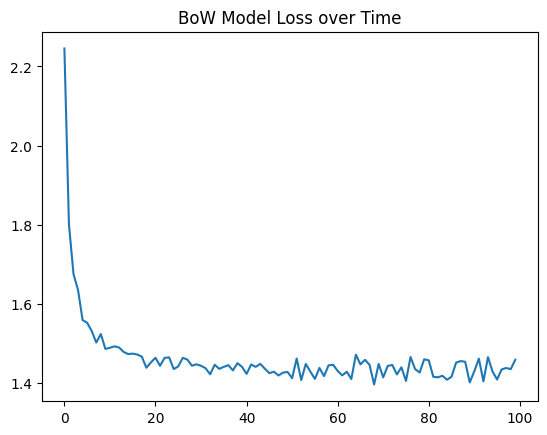

BoW train accuracy: 0.690625 | test accuracy: 0.471
--- Training N-Gram Model ---
epoch 0 loss [2.19103877]
epoch 10 loss [1.47219834]
epoch 20 loss [1.40874958]
epoch 30 loss [1.3751281]
epoch 40 loss [1.40668916]
epoch 50 loss [1.40659899]
epoch 60 loss [1.40517392]
epoch 70 loss [1.40272194]
epoch 80 loss [1.38921947]
epoch 90 loss [1.39948586]


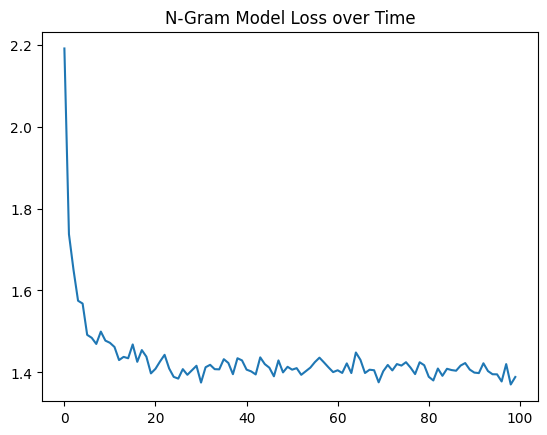

Gram train accuracy: 0.682375 | test accuracy: 0.4635

AI SENTIMENT PREDICTOR
-> BoW Model Prediction:    Negative 🙁
-> N-Gram Model Prediction: Negative 🙁
-> BoW Model Prediction:    Positive 🙂
-> N-Gram Model Prediction: Positive 🙂
-> BoW Model Prediction:    Very Positive 😍
-> N-Gram Model Prediction: Very Positive 😍


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

debug = 1  # Turn debug ON
X_data, y_data = read_data()

if debug == 1:
    # Limit data to 10,000 samples to fit into standard computer memory
    X_data = X_data[:10000]
    y_data = y_data[:10000]

y = np.array(y_data).reshape(len(y_data), 1)

# 1. Feature Extraction (UPDATED: Removed do_lower_case arguments!)
bag_of_word_model = BagOfWord()
ngram_model = NGram(ngram=(1,))

print("Extracting features... this might take a few seconds with the new text cleaner!")
X_Bow = bag_of_word_model.fit_transform(X_data)
X_Gram = ngram_model.fit_transform(X_data)

print("BoW shape", X_Bow.shape)
print("Gram shape", X_Gram.shape)

# 2. Split into Train and Test sets
X_train_Bow, X_test_Bow, y_train_Bow, y_test_Bow = train_test_split(
    X_Bow, y, test_size=0.2, random_state=42, stratify=y
)
X_train_Gram, X_test_Gram, y_train_Gram, y_test_Gram = train_test_split(
    X_Gram, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Setup Training Parameters
epoch = 100
bow_learning_rate = 1
gram_learning_rate = 1

# 4. Train Model 1 (Bag of Words)
print("--- Training BoW Model ---")
model1 = SoftmaxRegression()
history1 = model1.fit(
    X_train_Bow,
    y_train_Bow,
    epoch=epoch,
    learning_rate=bow_learning_rate,
    print_loss_steps=epoch // 10,
    update_strategy="stochastic",
)
plt.plot(np.arange(len(history1)), np.array(history1))
plt.title("BoW Model Loss over Time")
plt.show()
print(
    "BoW train accuracy: {} | test accuracy: {}".format(
        model1.score(X_train_Bow, y_train_Bow), model1.score(X_test_Bow, y_test_Bow)
    )
)

# 5. Train Model 2 (N-Gram)
print("--- Training N-Gram Model ---")
model2 = SoftmaxRegression()
history2 = model2.fit(
    X_train_Gram,
    y_train_Gram,
    epoch=epoch,
    learning_rate=gram_learning_rate,
    print_loss_steps=epoch // 10,
    update_strategy="stochastic",
)
plt.plot(np.arange(len(history2)), np.array(history2))
plt.title("N-Gram Model Loss over Time")
plt.show()
print(
    "Gram train accuracy: {} | test accuracy: {}".format(
        model2.score(X_train_Gram, y_train_Gram), model2.score(X_test_Gram, y_test_Gram)
    )
)

# 6. Real-time Inference Loop
print("\n" + "=" * 30)
print("AI SENTIMENT PREDICTOR")
print("=" * 30)

# Map the numerical outputs back to human-readable strings
sentiment_map = {
    0: "Very Negative 😠",
    1: "Negative 🙁",
    2: "Neutral 😐",
    3: "Positive 🙂",
    4: "Very Positive 😍",
}

In [ ]:
while True:
    user_input = input("\nEnter a movie review (or type 'exit' to quit): ")

    if user_input.lower() == "exit":
        break

    # Put the single sentence into a list so the transform method can process it
    test_phrase = [user_input]

    # Step A: Transform the text into numerical features
    bow_features = bag_of_word_model.transform(test_phrase)
    gram_features = ngram_model.transform(test_phrase)

    # Step B: Get predictions from both models
    bow_prediction = model1.predict(bow_features)[0]
    gram_prediction = model2.predict(gram_features)[0]

    # Step C: Display results
    print(f"-> BoW Model Prediction:    {sentiment_map[bow_prediction]}")
    print(f"-> N-Gram Model Prediction: {sentiment_map[gram_prediction]}")